Part 1.1 - Sine-wave GAN


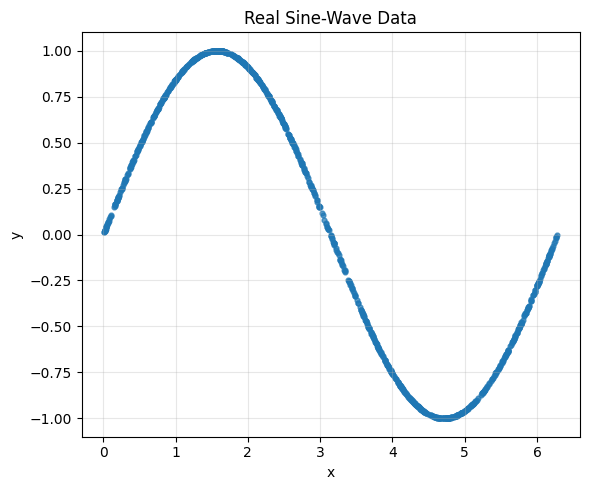

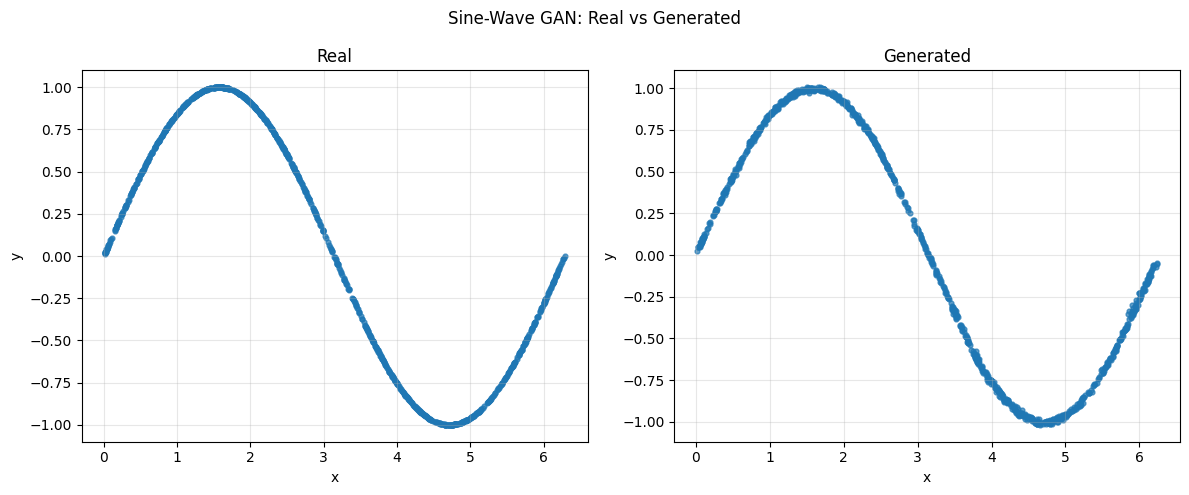

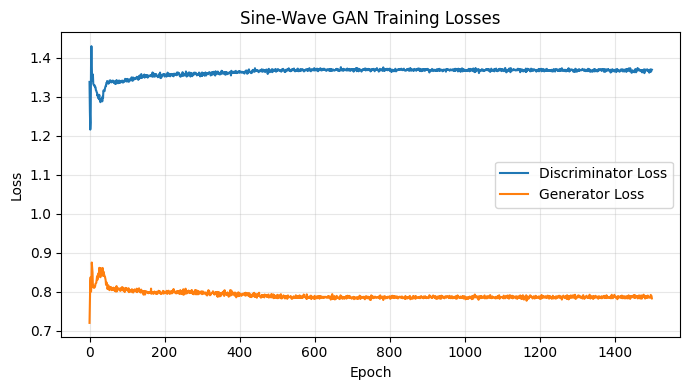

In [1]:
#part 1: reproducing the sine wave from the tutorial
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

#sinewave dataset

def make_sine_wave_data(n_samples=1024):
    x = 2 * math.pi * torch.rand(n_samples)
    y = torch.sin(x)
    data = torch.stack([x, y], dim=1)
    return data

#normalization
def normalize_points(data):
    mean = data.mean(dim=0, keepdim=True)
    std = data.std(dim=0, keepdim=True) + 1e-8
    normalized = (data - mean) / std
    return normalized, mean, std

def denormalize_points(data, mean, std):
    return data * std + mean

#data loader
def make_2d_loader(data, batch_size=64):
    dummy_labels = torch.zeros(len(data))
    dataset = TensorDataset(data, dummy_labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

#plotting
def plot_2d_points(data, title):
    arr = data.detach().cpu().numpy()
    plt.figure(figsize=(6, 5))
    plt.scatter(arr[:, 0], arr[:, 1], s=12, alpha=0.7)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def compare_real_generated(real_data, fake_data, title):
    real_arr = real_data.detach().cpu().numpy()
    fake_arr = fake_data.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(real_arr[:, 0], real_arr[:, 1], s=12, alpha=0.7)
    axes[0].set_title("Real")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(fake_arr[:, 0], fake_arr[:, 1], s=12, alpha=0.7)
    axes[1].set_title("Generated")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_training_losses(d_losses, g_losses, title):
    plt.figure(figsize=(7, 4))
    plt.plot(d_losses, label="Discriminator Loss")
    plt.plot(g_losses, label="Generator Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#GAN
class SineGenerator(nn.Module):
    def __init__(self, latent_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.net(z)

class SineDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

#GAN training
def train_sine_gan(generator, discriminator, loader, latent_dim=4, epochs=1500, lr_g=0.0005, lr_d=0.0003):
    criterion = nn.BCELoss()

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for real_batch, _ in loader:
            batch_size = real_batch.size(0)

            real_targets = 0.9 * torch.ones(batch_size, 1)
            fake_targets = torch.zeros(batch_size, 1)

            #discriminator
            optimizer_d.zero_grad()

            real_preds = discriminator(real_batch)
            d_loss_real = criterion(real_preds, real_targets)

            noise = torch.randn(batch_size, latent_dim)
            fake_batch = generator(noise)

            fake_preds = discriminator(fake_batch.detach())
            d_loss_fake = criterion(fake_preds, fake_targets)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_d.step()

            #generator
            optimizer_g.zero_grad()

            noise = torch.randn(batch_size, latent_dim)
            generated_batch = generator(noise)
            gen_preds = discriminator(generated_batch)

            g_loss = criterion(gen_preds, real_targets)
            g_loss.backward()
            optimizer_g.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        d_losses.append(epoch_d_loss / len(loader))
        g_losses.append(epoch_g_loss / len(loader))

    return generator, d_losses, g_losses

#fake sample generator
def generate_sine_samples(generator, n_samples=1000, latent_dim=4):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n_samples, latent_dim)
        samples = generator(noise)
    return samples

sine_data = make_sine_wave_data(n_samples=1024)
plot_2d_points(sine_data, "Real Sine-Wave Data")

sine_normalized, sine_mean, sine_std = normalize_points(sine_data)
sine_loader = make_2d_loader(sine_normalized, batch_size=64)

sine_generator = SineGenerator(latent_dim=4)
sine_discriminator = SineDiscriminator()

sine_generator, sine_d_losses, sine_g_losses = train_sine_gan(
    generator=sine_generator,
    discriminator=sine_discriminator,
    loader=sine_loader,
    latent_dim=4,
    epochs=1500,
    lr_g=0.0005,
    lr_d=0.0003
)

sine_fake = generate_sine_samples(sine_generator, n_samples=1000, latent_dim=4)
sine_fake = denormalize_points(sine_fake, sine_mean, sine_std)

compare_real_generated(sine_data, sine_fake, "Sine-Wave GAN: Real vs Generated")
plot_training_losses(sine_d_losses, sine_g_losses, "Sine-Wave GAN Training Losses")

part2. Custom 2d GAN

In [2]:
import math
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

Generating mixure of Gaussian Datasets.

In [3]:
#no. of training samples
train_data_length = 1024

#gauss clusters
centers = torch.tensor([
    [2.0, 2.0],
    [2.0, -2.0],
    [-2.0, 2.0],
    [-2.0, -2.0]
])

std = 0.2

#sampling equally from 4 clusters.
samples_per_cluster = train_data_length // len(centers)
train_data_list = []

for center in centers:
    cluster_samples = center + std * torch.randn(samples_per_cluster, 2)
    train_data_list.append(cluster_samples)

train_data = torch.cat(train_data_list, dim=0)

#labels (fake)
train_labels = torch.zeros(train_data.size(0))

#(sample, label) => Tuples
train_set = [(train_data[i], train_labels[i]) for i in range(train_data.size(0))]

print("train_data shape:", train_data.shape)
print("first 5 samples:\n", train_data[:5])

train_data shape: torch.Size([1024, 2])
first 5 samples:
 tensor([[2.3854, 2.2975],
        [2.1801, 1.5789],
        [2.1357, 1.7531],
        [1.9914, 1.6791],
        [1.8496, 2.3297]])


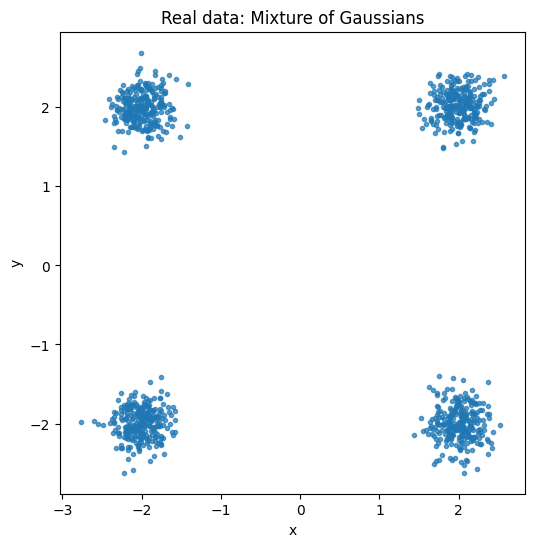

In [4]:
plt.figure(figsize=(6, 6))
plt.plot(train_data[:, 0], train_data[:, 1], ".", alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Real data: Mixture of Gaussians")
plt.axis("equal")
plt.show()

In [5]:
#creating dataloader
from torch.utils.data import DataLoader

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

In [6]:
#baseline discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        output = self.model(x)
        return output

discriminator = Discriminator()
print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [7]:
#baseline generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        output = self.model(x)
        return output

generator = Generator()
print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [8]:
#training
lr = 0.001
num_epochs = 2000

loss_function = nn.BCELoss()

#optimizer
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

print("Learning rate:", lr)
print("Number of epochs:", num_epochs)
print("Loss function:", loss_function)

Learning rate: 0.001
Number of epochs: 2000
Loss function: BCELoss()


In [9]:
#train baseline GAN
discriminator_losses = []
generator_losses = []

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):

        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))

        #combine real and fake data
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))


        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        #new latent sample generation
        latent_space_samples = torch.randn((batch_size, 2))

        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
        loss_generator.backward()
        optimizer_generator.step()


    discriminator_losses.append(loss_discriminator.item())
    generator_losses.append(loss_generator.item())

    #print every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss D: {loss_discriminator.item():.4f} | Loss G: {loss_generator.item():.4f}")

Epoch: 0 | Loss D: 0.1087 | Loss G: 2.0291
Epoch: 100 | Loss D: 0.5379 | Loss G: 1.0734
Epoch: 200 | Loss D: 0.3958 | Loss G: 1.0733
Epoch: 300 | Loss D: 0.3938 | Loss G: 1.0753
Epoch: 400 | Loss D: 0.4114 | Loss G: 1.2646
Epoch: 500 | Loss D: 0.4460 | Loss G: 1.1157
Epoch: 600 | Loss D: 0.4527 | Loss G: 1.0827
Epoch: 700 | Loss D: 0.4449 | Loss G: 1.0732
Epoch: 800 | Loss D: 0.5128 | Loss G: 1.4589
Epoch: 900 | Loss D: 0.4964 | Loss G: 1.0437
Epoch: 1000 | Loss D: 0.4713 | Loss G: 1.0987
Epoch: 1100 | Loss D: 0.4216 | Loss G: 1.1209
Epoch: 1200 | Loss D: 0.4979 | Loss G: 1.1773
Epoch: 1300 | Loss D: 0.4497 | Loss G: 1.0305
Epoch: 1400 | Loss D: 0.4381 | Loss G: 1.0919
Epoch: 1500 | Loss D: 0.4561 | Loss G: 1.1078
Epoch: 1600 | Loss D: 0.4674 | Loss G: 1.0789
Epoch: 1700 | Loss D: 0.4549 | Loss G: 1.3456
Epoch: 1800 | Loss D: 0.4288 | Loss G: 1.1472
Epoch: 1900 | Loss D: 0.5169 | Loss G: 1.1453


In [10]:
#baseline results
#1000 random 2d latent points
latent_space_samples = torch.randn(1000, 2)

#fake samples
generated_samples = generator(latent_space_samples)

#numpy=>plotting
generated_samples_numpy = generated_samples.detach().numpy()
train_data_numpy = train_data.detach().numpy()

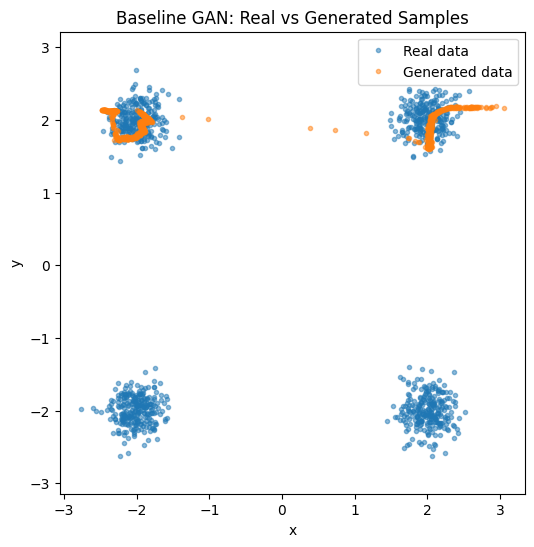

In [11]:
plt.figure(figsize=(6, 6))
plt.plot(train_data_numpy[:, 0], train_data_numpy[:, 1], ".", label="Real data", alpha=0.5)
plt.plot(generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", label="Generated data", alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Baseline GAN: Real vs Generated Samples")
plt.legend()
plt.axis("equal")
plt.show()

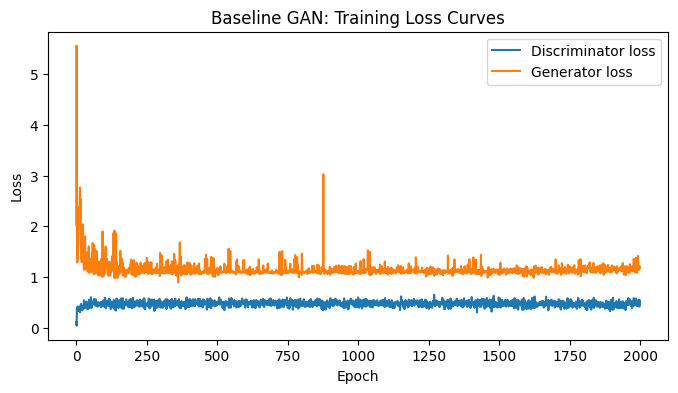

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(discriminator_losses, label="Discriminator loss")
plt.plot(generator_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline GAN: Training Loss Curves")
plt.legend()
plt.show()

Modified Architecture

In [13]:
#modified disc.
class DiscriminatorModified(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

modified_discriminator = DiscriminatorModified()
print(modified_discriminator)

DiscriminatorModified(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [14]:
#modified Gen.
class GeneratorModified(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.model(x)

modified_generator = GeneratorModified()
print(modified_generator)

GeneratorModified(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [15]:
#training modified GAN

modified_lr = 0.001
modified_num_epochs = 2000


modified_loss_function = nn.BCELoss()

#optimizer
optimizer_modified_discriminator = torch.optim.Adam(
    modified_discriminator.parameters(), lr=modified_lr
)
optimizer_modified_generator = torch.optim.Adam(
    modified_generator.parameters(), lr=modified_lr
)

print("Learning rate:", modified_lr)
print("Number of epochs:", modified_num_epochs)
print("Loss function:", modified_loss_function)

Learning rate: 0.001
Number of epochs: 2000
Loss function: BCELoss()


In [16]:
#training modified GAN
modified_discriminator_losses = []
modified_generator_losses = []

for epoch in range(modified_num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):

        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = modified_generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))

        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        modified_discriminator.zero_grad()
        output_discriminator = modified_discriminator(all_samples)
        loss_discriminator = modified_loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_modified_discriminator.step()

        latent_space_samples = torch.randn((batch_size, 2))

        modified_generator.zero_grad()
        generated_samples = modified_generator(latent_space_samples)
        output_discriminator_generated = modified_discriminator(generated_samples)
        loss_generator = modified_loss_function(output_discriminator_generated, real_samples_labels)
        loss_generator.backward()
        optimizer_modified_generator.step()

    modified_discriminator_losses.append(loss_discriminator.item())
    modified_generator_losses.append(loss_generator.item())

    #every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss D: {loss_discriminator.item():.4f} | Loss G: {loss_generator.item():.4f}")

Epoch: 0 | Loss D: 0.3170 | Loss G: 1.0132
Epoch: 100 | Loss D: 0.6508 | Loss G: 0.7907
Epoch: 200 | Loss D: 0.7046 | Loss G: 0.8287
Epoch: 300 | Loss D: 0.6644 | Loss G: 0.7277
Epoch: 400 | Loss D: 0.6828 | Loss G: 0.8023
Epoch: 500 | Loss D: 0.6913 | Loss G: 0.7971
Epoch: 600 | Loss D: 0.6841 | Loss G: 0.7121
Epoch: 700 | Loss D: 0.6678 | Loss G: 0.7004
Epoch: 800 | Loss D: 0.6718 | Loss G: 0.8144
Epoch: 900 | Loss D: 0.6753 | Loss G: 0.7226
Epoch: 1000 | Loss D: 0.6779 | Loss G: 0.7771
Epoch: 1100 | Loss D: 0.6805 | Loss G: 0.6791
Epoch: 1200 | Loss D: 0.6810 | Loss G: 0.7280
Epoch: 1300 | Loss D: 0.6942 | Loss G: 0.7844
Epoch: 1400 | Loss D: 0.6954 | Loss G: 0.7039
Epoch: 1500 | Loss D: 0.6760 | Loss G: 0.7551
Epoch: 1600 | Loss D: 0.6795 | Loss G: 0.8242
Epoch: 1700 | Loss D: 0.7063 | Loss G: 0.6792
Epoch: 1800 | Loss D: 0.7027 | Loss G: 0.7007
Epoch: 1900 | Loss D: 0.6813 | Loss G: 0.7617


Modified Result Discussion

In [17]:
#1000 random 2d latent points
modified_latent_space_samples = torch.randn(1000, 2)

#fake samples => modified Generator
modified_generated_samples = modified_generator(modified_latent_space_samples)
modified_generated_samples_numpy = modified_generated_samples.detach().numpy()

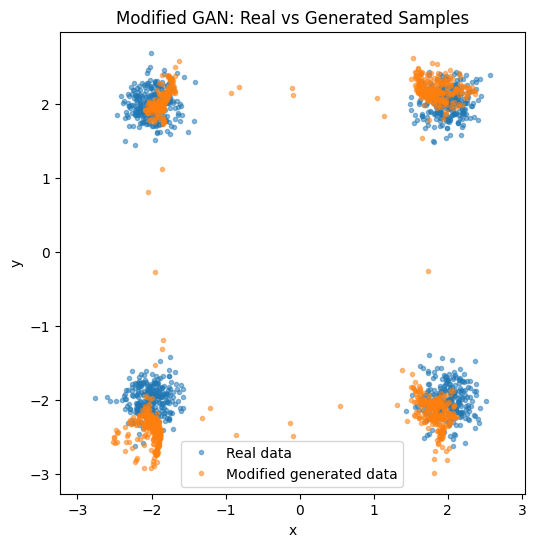

In [18]:
plt.figure(figsize=(6, 6))
plt.plot(train_data_numpy[:, 0], train_data_numpy[:, 1], ".", label="Real data", alpha=0.5)
plt.plot(modified_generated_samples_numpy[:, 0], modified_generated_samples_numpy[:, 1], ".", label="Modified generated data", alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Modified GAN: Real vs Generated Samples")
plt.legend()
plt.axis("equal")
plt.show()

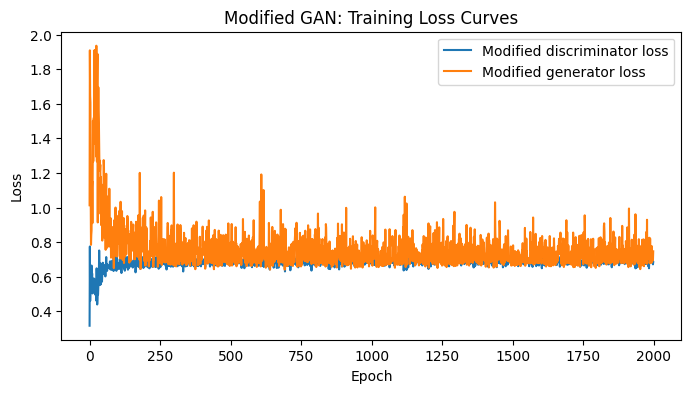

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(modified_discriminator_losses, label="Modified discriminator loss")
plt.plot(modified_generator_losses, label="Modified generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modified GAN: Training Loss Curves")
plt.legend()
plt.show()